# 02 — Limpeza da série-alvo

Objetivo: construir a série semanal de preço de revenda do **Diesel S10 no RS**. Os CSVs são percorridos em chunks de 100 mil linhas, mantendo em memória somente as sete colunas necessárias e as observações do alvo. Nenhum arquivo em `raw/` é alterado.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_cleaning import (
    build_weekly_target,
    find_revenda_files,
    load_target_observations,
    save_target_data,
)

## 1. Localizar os arquivos de revenda

In [2]:
files = find_revenda_files(PROJECT_ROOT / 'raw')
assert files, 'Nenhum CSV de revenda foi encontrado.'
pd.DataFrame({'arquivo': files, 'tamanho_mb': [round(p.stat().st_size / 1_048_576, 2) for p in files]})

,arquivo,tamanho_mb
0,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,77.60
1,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,68.47
2,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,68.57
3,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,60.79
4,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,68.78


## 2. Filtrar e padronizar

Esta é a única etapa demorada: todos os arquivos são percorridos, mas nunca carregados integralmente em memória.

In [3]:
observations, diagnostics = load_target_observations(
    files, uf='RS', product='DIESEL S10', chunksize=100_000
)
diagnostics

,arquivo,linhas_lidas,linhas_alvo,datas_invalidas,precos_invalidos
0,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,477154,6518,0,0
1,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,421382,5988,0,0
2,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,429523,6254,0,0
3,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,384208,5513,0,0
4,C:\Users\Wesley.Barbaro\Documents\dados\raw\an...,422418,5648,0,0


In [4]:
assert not observations.empty, 'O filtro não encontrou Diesel S10 no RS.'
display(observations.head())
display(observations.dtypes)
observations[['data_coleta', 'preco_venda']].describe()

,uf,municipio,revenda,cnpj,produto,data_coleta,preco_venda,arquivo_origem
0,RS,GUAIBA,ABASTECEDORA DE COMBUSTIVEIS RIOXEL LTDA,03358858000706,DIESEL S10,2024-01-01,5.99,Preços semestrais - AUTOMOTIVOS_2024.01.csv
1,RS,GUAIBA,ABASTECEDORA DE COMBUSTIVEIS RIOXEL LTDA,03358858000897,DIESEL S10,2024-01-01,5.99,Preços semestrais - AUTOMOTIVOS_2024.01.csv
2,RS,GUAIBA,ABASTECEDORA DE COMBUSTIVEIS RIOXEL LTDA,03358858001788,DIESEL S10,2024-01-01,5.99,Preços semestrais - AUTOMOTIVOS_2024.01.csv
3,RS,GUAIBA,DISTRIBUIDORA DE COMBUSTIVEIS PARQUE 35 LTDA,11474022000100,DIESEL S10,2024-01-01,5.95,Preços semestrais - AUTOMOTIVOS_2024.01.csv
4,RS,GUAIBA,COMERCIO DE COMBUSTIVEIS DO IVAN LTDA,86914942000281,DIESEL S10,2024-01-01,5.89,Preços semestrais - AUTOMOTIVOS_2024.01.csv


uf                           str
municipio                 string
revenda                   string
cnpj                      string
produto                      str
data_coleta       datetime64[us]
preco_venda              Float64
arquivo_origem               str
dtype: object

,data_coleta,preco_venda
count,29921,29921.0
mean,2025-03-17 06:14:42.884930,6.270983
min,2024-01-01 00:00:00,5.09
25%,2024-07-30 00:00:00,5.99
50%,2025-03-11 00:00:00,6.19
75%,2025-11-04 00:00:00,6.48
max,2026-06-30 00:00:00,8.99
std,NaN,0.452847


## 3. Agregar por semana

A semana vai de segunda-feira a domingo. Coletas repetidas do mesmo posto no mesmo dia são consolidadas pela mediana antes da agregação estadual. Semanas ausentes são marcadas, não preenchidas.

In [5]:
weekly, quality = build_weekly_target(observations)
display(pd.Series(quality, name='valor').to_frame())
display(weekly.head())
display(weekly.tail())

,valor
primeira_coleta,2024-01-01
ultima_coleta,2026-06-30
observacoes_validas,29921
posto_dias,29919
linhas_em_chaves_repetidas_posto_dia,4
semanas_no_calendario,131
semanas_sem_dados,0
convencao_semanal,segunda-feira a domingo; semana_fim e domingo
imputacao_de_preco,nenhuma


,semana_fim,preco_medio,preco_mediano,preco_minimo,preco_maximo,preco_desvio_padrao,numero_observacoes,numero_postos,numero_municipios,semana_sem_dados
0,2024-01-07,6.005394,5.99,5.47,6.8,0.28829,254,254,35,False
1,2024-01-14,6.022038,5.99,5.49,6.99,0.281867,260,260,33,False
2,2024-01-21,5.998178,5.99,5.47,6.9,0.287353,269,269,36,False
3,2024-01-28,5.955099,5.96,5.09,6.9,0.28668,253,253,34,False
4,2024-02-04,5.957235,5.96,5.39,6.99,0.270158,264,264,34,False


,semana_fim,preco_medio,preco_mediano,preco_minimo,preco_maximo,preco_desvio_padrao,numero_observacoes,numero_postos,numero_municipios,semana_sem_dados
126,2026-06-07,6.955926,6.89,6.29,8.04,0.333309,216,216,33,False
127,2026-06-14,6.925493,6.89,6.29,8.04,0.326351,213,213,33,False
128,2026-06-21,6.885196,6.79,6.27,8.04,0.353963,204,204,34,False
129,2026-06-28,6.855327,6.79,6.09,8.04,0.366353,214,214,33,False
130,2026-07-05,6.819051,6.79,6.09,8.04,0.364777,158,158,23,False


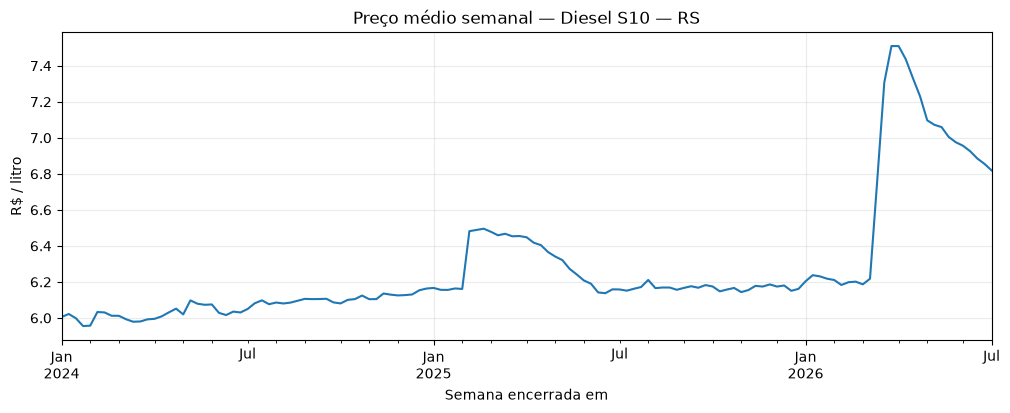

In [6]:
ax = weekly.plot(
    x='semana_fim', y='preco_medio', figsize=(12, 4), legend=False,
    title='Preço médio semanal — Diesel S10 — RS'
)
ax.set(xlabel='Semana encerrada em', ylabel='R$ / litro')
ax.grid(alpha=0.25)
plt.show()

## 4. Checagens que devem ser avaliadas

Não prossiga para modelagem se houver semanas sem dados, queda brusca no número de postos ou preços claramente impossíveis.

In [7]:
display(weekly.loc[weekly['semana_sem_dados']])
display(weekly.nsmallest(10, 'numero_postos')[['semana_fim', 'numero_postos', 'numero_municipios', 'preco_medio']])
display(weekly.loc[(weekly['preco_minimo'] < 2) | (weekly['preco_maximo'] > 15)])

,semana_fim,preco_medio,preco_mediano,preco_minimo,preco_maximo,preco_desvio_padrao,numero_observacoes,numero_postos,numero_municipios,semana_sem_dados


,semana_fim,numero_postos,numero_municipios,preco_medio
130,2026-07-05,158,23,6.819051
82,2025-08-03,169,23,6.210888
19,2024-05-19,174,26,6.078966
18,2024-05-12,177,25,6.097458
90,2025-09-28,177,25,6.182429
83,2025-08-10,179,24,6.165587
87,2025-09-07,181,24,6.166961
80,2025-07-20,192,25,6.161979
123,2026-05-17,192,31,7.059583
76,2025-06-22,195,27,6.137436


,semana_fim,preco_medio,preco_mediano,preco_minimo,preco_maximo,preco_desvio_padrao,numero_observacoes,numero_postos,numero_municipios,semana_sem_dados


## 5. Salvar resultados

Execute esta célula somente depois de conferir as tabelas e o gráfico acima.

In [8]:
output_paths = save_target_data(
    observations, weekly, diagnostics, quality,
    PROJECT_ROOT / 'processed' / 'anp' / 'revenda',
)
output_paths

{'observacoes': WindowsPath('C:/Users/Wesley.Barbaro/Documents/dados/processed/anp/revenda/diesel_s10_rs_observacoes.csv'),
 'semanal': WindowsPath('C:/Users/Wesley.Barbaro/Documents/dados/processed/anp/revenda/diesel_s10_rs_semanal.csv'),
 'diagnostico': WindowsPath('C:/Users/Wesley.Barbaro/Documents/dados/processed/anp/revenda/diesel_s10_rs_diagnostico_arquivos.csv'),
 'qualidade': WindowsPath('C:/Users/Wesley.Barbaro/Documents/dados/processed/anp/revenda/diesel_s10_rs_qualidade.json')}

## Próximo passo

Depois de validar a cobertura, criar o baseline ingênuo semanal. Brent e dólar só serão integrados após esse baseline.